# PMD: Penalized Matrix Decomposition

Penalized Matrix Decomposition or PMD is a matrix decomposition technique which is used for factoring a data matrix into small number of ranked one matrices along with a $L_1$ penalization that enforces most of the loadings to be $0$.  

In Singular Value Decomposition or SVD, a matrix $X$ is represented as a sum of ranked one matrices as $X = \Sigma d_k u_k v_k'$ where $u_k$ and **v_k** are orthonormal singular vectors and $d_k$ are singular values. In PMD, this ranked one representation can be transformed into an optimization problem by considering unit vectors $u$ and $v$ which maximize $u' X v$ while imposing constraints on $u$ and $v$. Hence, in PMD, we consider the following optimization problem: $$\max u' X v \text{ subject to the constraint }  ‖u‖_2 \le 1 \text{, }‖v‖_2 \le 1 \text{, }P_1(u) \le c_1\text{, }P_2(v) \le c_2.$$ We choose the penalties $P_1$ and $P_2$ to be L1 (lasso) penalties. This produces sparsity as $L_1$ budges makes many entries $u$ and $v$ to be exavtly $0$ making each components to be supported ny only a few observations and variables. The parameters in `pmd`: `sumabs` (or `sumabsu`, `sumabsv`) set how large the $L_1$ norm of each factor will be where smaller budgets give sparser factors.

The optimization problem mentioned above is solved by an alternating algorithm where we keep $v$ fixed first and solve for $u$ using a soft thresholding step. Then we solve for $v$ by holding $u$ fixed. Additional components are obtained in a similar fashion as done in SVD where we remove the fitted ranked one piece from $X$ and repeat on the residual.


In this documentation, we will depomstrate implementation of PMD using `BigRiverSchneider.pmd` on a breast cancer dataset. 

## The data

The dataset used in this study contains DNA copy-number measurements at 2149 genomic locations (CGH
spots) across 89 breast cancer samples along with chromosome and position of each spot. 



In [8]:
using Pkg
Pkg.activate("/Users/abhisekbanerjee/Desktop/UTHSC internship/Julia/BigRiverSchneider.jl")
using BigRiverSchneider
const BRS = BigRiverSchneider
using RCall, Plots, Statistics
gr()

  Activating project at `~/Desktop/UTHSC internship/Julia/BigRiverSchneider.jl`


Plots.GRBackend()

In [ ]:
R"""
suppressMessages(library(PMA))
breast <- download_breast_data(url = "https://tibshirani.su.domains/PMA/breastdata.rda")
dna_t <- t(breast$dna)          # samples on rows, CGH spots on columns
chrom <- breast$chrom
nuc   <- breast$nuc
"""

# Copy the R objects into Julia variables
dna   = rcopy(R"dna_t")         # 89 × 2149 Matrix{Float64}
chrom = Int.(rcopy(R"chrom"))   # 2149 chromosome labels
nuc   = rcopy(R"nuc")           # 2149 genomic positions

size(dna), length(chrom)

┌ Warning: RCall.jl: trying URL 'https://tibshirani.su.domains/PMA/breastdata.rda'
│ Content type 'application/octet-stream' length 6619048 bytes (6.3 MB)
│ ==================================================
│ downloaded 6.3 MB
│ 
└ @ RCall /Users/abhisekbanerjee/.julia/packages/RCall/fTLHT/src/io.jl:166


((89, 2149), 2149)

## The method summary

- We will center the data matrix (and can optionally standardize it).
- We will then find a rank-one approximation of the matrix, essentially a pair of factors u and v. Both of them will have $L_1$ penalty. This will force most of their entries to be $0$. This will make the factors sparse where each component will use only a few observations and a few variables.
- The strength of the penalty is set by `sumabs` (smaller values give sparser factors), and the factors are found by an alternating soft-thresholding algorithm that updates u and v in turn until they converge.
- To obtain further components, we remove the fitted rank-one piece from the matrix and repeat on what remains (deflation), just as the SVD builds up a matrix one rank-one piece at a time.

## Fitting the model

Now we fit the `pmd` function to the `dna` matrix which has 89 samples × 2149 genomic spots. The argument `sumabs = 0.4` sets the sparsity budget. Here we consider a single ranked one component, hence we set `K = 1`. We use `center = true` that subtracts the grand mean before decomposing.


In [10]:
m = BRS.pmd(dna; sumabs = 0.4, K = 1, center = true)

pmdStructure{Float64}([-0.0; -0.13915922200986136; … ; -0.11028453081906671; -0.0;;], [0.013686697414503185; 0.008027453250870745; … ; 0.008202488467035774; 0.0042770173263478005;;], [35.04445883312545], 3.7735924528226414, 18.542923178398816, 1, 0.011720450424812167)

The result in `m` containts the sparse left and right factors (`m.u`, `m.v`) and the weight
`m.d`. The right factor `m.v` is a 2149 long loading vector containing one value per
genomic spot where most of them exactly are $0$.

## The sparse copy-number signature

Each of the 2149 genomic spots which are our variables gets one loading value in `m.v` which are its weight in the
sparse component. Since $L_1$ penalty of PMD drives most of those to $0$, the
loading vector is mostly zeros with a small number of nonzero values. To get an idea of where those
nonzero entries are falling, we can plot each spot's loading against its ordering along the
genome (where spots are arranged chromosome by chromosome, position by position), and color
each point by the chromosome it belongs to. The result will be a genome wide view where a flat
line of zeros will be interrupted by clusters of nonzero loadings, each cluster marking a
genomic region that PMD selected as varying across the samples.

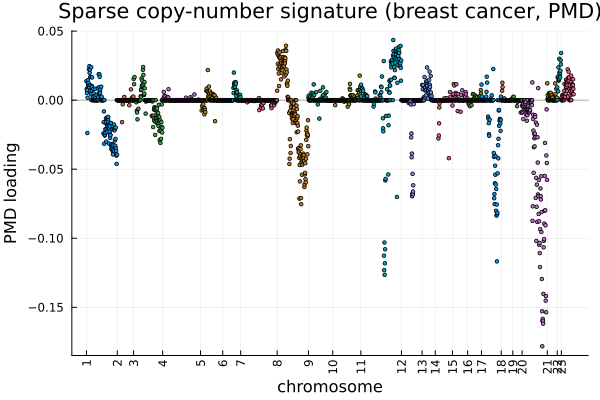

In [11]:
v = m.v[:, 1]
# find where each chromosome starts, to place labels
chrom_ids = unique(chrom)
tick_pos = [findfirst(==(c), chrom) for c in chrom_ids]

scatter(1:length(v), v; group = chrom, markersize = 2, legend = false,
    xticks = (tick_pos, string.(chrom_ids)), xrotation = 90,
    xlabel = "chromosome", ylabel = "PMD loading",
    title = "Sparse copy-number signature (breast cancer, PMD)")
hline!([0], color = :black, alpha = 0.3)

With genomic position on the x-axis, each nonzero loading marks a spot where the copy
number changes together across samples. The nonzero spots cluster into a contiguous
stretch rather than scattering randomly. That contiguity is the signature of a real
copy-number alteration, since gains and losses affect whole chromosomal segments at
once, not isolated points. The zeroed spots on either side are the regions PMD considered
uninvolved.

## Summary


Here we demonstrated the use of PMD using the `pmd` function from the Julia package `BigRiverSchneider.jl`. PMD can also be applied to any similar dataset.



